In [1]:
# I want to do a simultaneous evaluation of the POIs and compute the correlation matrix
import uproot
import os
import glob
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.colors import LinearSegmentedColormap
import mplhep as hep
import seaborn as sns
import ROOT
import pandas as pd
from scipy import stats
import numpy as np
from scipy.optimize import minimize, curve_fit
from scipy.stats import moment
import json
from itertools import combinations
import yaml


Welcome to JupyROOT 6.30/04


In [2]:
# Importing translation dictionary
translationFilePath = "/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/translation.json"
with open(translationFilePath) as translationFile:
    translation = json.load(translationFile)

In [3]:
# Do everything untrimmed, i.e., include failed fits as -999. Then combine every considered variable into a big json file.
# Should we do a trimming??
def pois_untrimmed(toyDir_, poi_list_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    # for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):
    for i in range(len(glob.glob(os.path.join(toyDir_, "bootstrap_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.root")
            current_root_files = uproot.open(f"{toyDir_}/bootstrap_{i}/higgsCombineBootstrapFit.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [4]:
def pois_trimmed(toyDir_, poi_list_, trimming_value_left_, trimming_value_right_):
    pois = {}

    for current_poi in poi_list_:

        pois[current_poi] = []

    # for i in range(len(glob.glob(os.path.join(toyDir_, "toy_*")))):
    for i in range(len(glob.glob(os.path.join(toyDir_, "bootstrap_*")))):

        if i%100==0:
            print(f"Processing fit_{i}")

        try:
            # current_root_files = uproot.open(f"{toyDir_}/toy_{i}/higgsCombineToyFit.MultiDimFit.mH125.root")
            current_root_files = uproot.open(f"{toyDir_}/bootstrap_{i}/higgsCombineBootstrapFit.MultiDimFit.mH125.38.root")
        except:
            print(f"Skipping fit_{i}: Required scan files not found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        kill_event = False

        # First loop to check if there are outliers (outliers are events smaller than -4 and bigger than 4)
        for j, current_poi in enumerate(poi_list_):
            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                pois[current_poi].append(-999.0)
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if (current_limit_values[0] > trimming_value_right_) or (current_limit_values[0] < trimming_value_left_):
                    kill_event = True 
                    break
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                pois[current_poi].append(-999.0)
                continue

        if kill_event:
            print(f"Skipping fit_{i} with {current_limit_values[0]}: Outlier found")
            for current_poi in poi_list_:
                pois[current_poi].append(-999.0)
            continue

        for j, current_poi in enumerate(poi_list_):

            try: 
                current_tree = current_root_files["limit"]
            except:
                print(f"Skipping fit_{i}: Tree 'limit' not found in ROOT file")
                continue

            current_limit_values = current_tree[current_poi].array()

            try:
                if current_limit_values[0]<-4:
                    print("Value out of boundary", current_limit_values[0], i)
            except:
                if j == 0:
                    print("Empty ROOT file for bootstrap: ", i)
                continue

            pois[current_poi].append(float(current_limit_values[0]))
    return pois

In [5]:
def gaus(x, amp, mu, sigma):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2))

def create_json_trimmed(variable_, toyDir_, pois_untrimmed_, poi_list_, subfolder_, extra_name=""):

    # Now we have to fit a gaussian core to all the categories to get the values where we cut. z is the number of standard deviations we want to cut away
    trimming_value_left = 0
    trimming_value_right = 0
    largest_sigma = 0
    mu_to_largest_sigma = 0
    z = 4 # 4
    for i, current_poi in enumerate(poi_list_):
        r = np.array(pois_untrimmed_[current_poi])
        r = r[r > -998.0]
        mean = np.mean(r)
        s = np.std(r)
        # r = r[r < 5.0]
        
        bins = 30 # 30
        
        counts, bin_edges = np.histogram(r, bins=bins, density=False)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        popt, _ = curve_fit(gaus, bin_centers, counts, p0=[1, mean, s], maxfev=10000)
        amp_fit, mu_fit, sigma_fit = popt
        
        # Define the pull
        pull = (r - 1.0) / s
        mean_pull = np.mean(pull)
        s_pull = np.std(pull)
        skewness_pull = stats.skew(pull)
        kurtosis_pull = stats.kurtosis(pull)

        # Fit for the pulls
        counts_pull, bin_edges_pull = np.histogram(pull, bins=bins, density=False)
        bin_centers_pull = (bin_edges_pull[:-1] + bin_edges_pull[1:]) / 2

        popt_pull, _ = curve_fit(gaus, bin_centers_pull, counts_pull, p0=[1, 0.0, 1], maxfev=10000)
        amp_fit_pull, mu_fit_pull, sigma_fit_pull = popt_pull

        if i == 0:
            largest_sigma = sigma_fit
            mu_to_largest_sigma = mu_fit
        else:
            if (sigma_fit > largest_sigma):
                largest_sigma = sigma_fit
                mu_to_largest_sigma = mu_fit

        if (not os.path.exists(f"/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/{variable_}/{subfolder_}")) & (f"/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/{variable_}/{subfolder_}"!=""):
            os.makedirs(f"/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/{variable_}/{subfolder_}")
        

        plt.figure(figsize=(12, 8))
        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(r, bins=bins, density=False, alpha=0.6, label='S+B Toys') #30
        plt.plot(bin_centers, gaus(bin_centers, *popt), color='red', label='Fitted Gaussian')
        plt.axvline(mean, color='red', linestyle='--', label=f'Mean: {mean:.2f} ± {s:.2f}')
        plt.axvline(np.median(r), color='blue', linestyle='--', label=f'Median: {np.median(r):.2f}')
        plt.axvline(1.0, color='grey', linestyle='--', label=r'$\mu=1$')
        plt.legend()
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.savefig(f"/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/{variable_}/{subfolder_}/gaussian_fit_{current_poi}.png")
        plt.close()

        # Compute the pull
        plt.figure(figsize=(12, 8))

        # Get axis limits
        xlim = plt.xlim()
        ylim = plt.ylim()

        plt.style.use(hep.style.CMS)
        hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
        plt.hist(pull, bins=bins, density=False, alpha=0.6, label='Pull') #30
        plt.plot(bin_centers_pull, gaus(bin_centers_pull, *popt_pull), color='red', label='Fitted Gaussian')
        plt.text(
            xlim[0] + 0.9*(xlim[1] - xlim[0]),   # 70% across the x-axis
            ylim[0] + 0.8*(ylim[1] - ylim[0]),   # 80% up the y-axis
            f'Mean: {mean_pull:.2f}\nStd Dev: {s_pull:.2f}\nSkewness: {skewness_pull:.2f}\nKurtosis: {kurtosis_pull:.2f}',
            bbox=dict(facecolor='white', alpha=0.5)
        )
        plt.xlabel(f"{translation[f'{current_poi}']}")
        plt.ylabel(r'$N$')
        plt.grid()
        plt.savefig(f"/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/{variable_}/{subfolder_}/pull_{current_poi}.png")
        plt.close()

    trimming_value_left = mu_to_largest_sigma - z*largest_sigma
    trimming_value_right = mu_to_largest_sigma + z*largest_sigma

    print("Trimming values: ", trimming_value_left, trimming_value_right)

    if trimming_value_left > trimming_value_right:
        trimming_value_left, trimming_value_right = trimming_value_right, trimming_value_left

    if not os.path.exists(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_trimmed_{variable_}{extra_name}.json'):
        pois = pois_trimmed(toyDir_, poi_list_, trimming_value_left, trimming_value_right)
        # Save the POIs to a JSON file
        with open(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_trimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_trimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)
    
    return pois

In [6]:
def create_json_untrimmed_per_variable(variable_, toyDir_, poi_list_, extra_name=""):
    # Loop through all fit directories (fit_0, fit_1, etc.)
    if not os.path.exists(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_untrimmed_{variable_}{extra_name}.json'):
        pois = pois_untrimmed(toyDir_, poi_list_)
        # Save the POIs to a JSON file
        with open(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_untrimmed_{variable_}{extra_name}.json', 'w') as f:
            json.dump(pois, f)
    else:
        # Load the POIs from the JSON file
        with open(f'/t3home/niharrin/devel/work/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/pois_untrimmed_{variable_}{extra_name}.json', 'r') as f:
            pois = json.load(f)

    return pois

In [7]:
plot_dir = "Plots"
os.makedirs(plot_dir, exist_ok=True)
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_06_12/intermediateRun3/finalfits'
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_10_14_intermediate/finalfits_postBPix'
# sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_22/earlyRun3_powheg/finalfits'
sample_dir = '/pnfs/psi.ch/cms/trivcat/store/user/niharrin/ntuples/midRun3/samples/2025_09_16/earlyRun3/finalfits'

In [8]:
# Load PTH toys
variable = "PTH"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0", "r_PTH_350p0_10000p0"]
# poi_list = ["r_PTH_0p0_15p0", "r_PTH_15p0_30p0", "r_PTH_30p0_45p0", "r_PTH_45p0_80p0", "r_PTH_80p0_120p0", "r_PTH_120p0_200p0", "r_PTH_200p0_350p0"]


pois_untrimmed_PTH = create_json_untrimmed_per_variable(variable, toyDir, poi_list)
pois_PTH = create_json_trimmed(variable, toyDir, pois_untrimmed_PTH, poi_list, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_PTH, poi_list, variable)

Trimming values:  -0.34753511491752054 3.6555197593871087


In [9]:
# Load NJ toys
variable = "NJ"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_NJ = ["r_NJ_0p0_1p0", "r_NJ_1p0_2p0", "r_NJ_2p0_3p0", "r_NJ_3p0_100p0"]

pois_untrimmed_NJ = create_json_untrimmed_per_variable(variable, toyDir, poi_list_NJ)
pois_NJ = create_json_trimmed(variable, toyDir, pois_untrimmed_NJ, poi_list_NJ, subfolder_=f"SL_{variable}")

# plot_all_individual_correlation(pois_untrimmed_NJ, poi_list_NJ, variable)

Trimming values:  -1.6117756928654245 2.6978133319499973


In [10]:
# Load rapidity toys
variable = "rapidity"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_rapidity = ["r_YH_0p0_0p15", "r_YH_0p15_0p3", "r_YH_0p3_0p6", "r_YH_0p6_0p9", "r_YH_0p9_2p5"]

pois_untrimmed_rapidity = create_json_untrimmed_per_variable(variable, toyDir, poi_list_rapidity)
pois_rapidity = create_json_trimmed(variable, toyDir, pois_untrimmed_rapidity, poi_list_rapidity, subfolder_=f"SL_{variable}")

Trimming values:  -0.9884776731777318 3.562065446758454


In [49]:
# Load PTJ0 toys
variable = "PTJ0"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_PTJ0 = ["r_PTJ0_30p0_75p0", "r_PTJ0_75p0_120p0", "r_PTJ0_120p0_200p0", "r_PTJ0_200p0_10000p0"]

pois_untrimmed_PTJ0 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_PTJ0)
pois_PTJ0 = create_json_trimmed(variable, toyDir, pois_untrimmed_PTJ0, poi_list_PTJ0, subfolder_=f"SL_{variable}")

Trimming values:  -1.3579367731777365 5.019883508153724


In [12]:
# Load DPhiJ0J1 toys
variable = "DPhiJ0J1"

main_dir = os.path.join(sample_dir, variable+"_RandomizeAux_separateDatasets", "Combine", f"runFits_{variable}")
# main_dir = os.path.join(sample_dir, variable, "Combine", f"runFits_{variable}")
# toyDir = os.path.join(main_dir, "toyFit")
toyDir = os.path.join(main_dir, "bootstrapFit")

poi_list_DPhiJ0J1 = ["r_DPhiJ0J1_m3p1416_m2p0944", "r_DPhiJ0J1_m2p0944_m1p0472", "r_DPhiJ0J1_m1p0472_0p0", "r_DPhiJ0J1_0p0_1p0472", "r_DPhiJ0J1_1p0472_2p0944", "r_DPhiJ0J1_2p0944_3p1416"]

pois_untrimmed_DPhiJ0J1 = create_json_untrimmed_per_variable(variable, toyDir, poi_list_DPhiJ0J1)
pois_DPhiJ0J1 = create_json_trimmed(variable, toyDir, pois_untrimmed_DPhiJ0J1, poi_list_DPhiJ0J1, subfolder_=f"SL_{variable}")

Trimming values:  -5.383381529186104 5.839378281746421


In [13]:
# Drop first bin of PTJ0 (as it is identical to the first bin of NJ)
pois_PTJ0 = {key: pois_PTJ0[key] for key in list(pois_PTJ0.keys())[1:]}

In [50]:
df_PTH = pd.DataFrame(pois_PTH)
df_NJ = pd.DataFrame(pois_NJ)
df_PTJ0 = pd.DataFrame(pois_PTJ0)
df_DPhiJ0J1 = pd.DataFrame(pois_DPhiJ0J1)
df_rapidity = pd.DataFrame(pois_rapidity)

In [51]:
df_PTH_untrimmed = pd.DataFrame(pois_untrimmed_PTH)
df_NJ_untrimmed = pd.DataFrame(pois_untrimmed_NJ)
df_PTJ0_untrimmed = pd.DataFrame(pois_untrimmed_PTJ0)
df_DPhiJ0J1_untrimmed = pd.DataFrame(pois_untrimmed_DPhiJ0J1)
df_rapidity_untrimmed = pd.DataFrame(pois_untrimmed_rapidity)
mask_pth_untrimmed = (df_PTH_untrimmed != -999).all(axis=1)
mask_nj_untrimmed = (df_NJ_untrimmed != -999).all(axis=1)
mask_PTJ0_untrimmed = (df_PTJ0_untrimmed != -999).all(axis=1)
mask_DPhiJ0J1_untrimmed = (df_DPhiJ0J1_untrimmed != -999).all(axis=1)
mask_rapidity_untrimmed = (df_rapidity_untrimmed != -999).all(axis=1)
valid_rows_untrimmed = mask_pth_untrimmed & mask_nj_untrimmed & mask_PTJ0_untrimmed & mask_DPhiJ0J1_untrimmed & mask_rapidity_untrimmed
df_PTH_clean_untrimmed = df_PTH_untrimmed[valid_rows_untrimmed]
df_NJ_clean_untrimmed = df_NJ_untrimmed[valid_rows_untrimmed]
df_PTJ0_clean_untrimmed = df_PTJ0_untrimmed[valid_rows_untrimmed]
df_DPhiJ0J1_clean_untrimmed = df_DPhiJ0J1_untrimmed[valid_rows_untrimmed]
df_rapidity_clean_untrimmed = df_rapidity_untrimmed[valid_rows_untrimmed]

In [60]:
# # --- Step 1: Identify rows WITHOUT -999 in either DataFrame ---
# Mask for df_PTH (True = valid, False = -999)
# mask_pth = (df_PTH != -999).all(axis=1) 
mask_pth = (df_PTH_untrimmed != -999).all(axis=1) 

# # Mask for df_NJ (True = valid, False = -999)
# mask_nj = (df_NJ != -999).all(axis=1)
mask_nj = (df_NJ_untrimmed != -999).all(axis=1)

# # Mask for df_PTJ0 (True = valid, False = -999)
# mask_ptj0 = (df_PTJ0 != -999).all(axis=1)
mask_ptj0 = (df_PTJ0_untrimmed != -999).all(axis=1)

# # Mask for df_DPhiJ0J1 (True = valid, False = -999)
# mask_DPhiJ0J1 = (df_DPhiJ0J1 != -999).all(axis=1)
mask_DPhiJ0J1 = (df_DPhiJ0J1_untrimmed != -999).all(axis=1)

# Mask for df_rapidity (True = valid, False = -999)
# mask_rapidity = (df_rapidity != -999).all(axis=1)
mask_rapidity = (df_rapidity_untrimmed != -999).all(axis=1)

# Combined mask (keep only rows valid in BOTH DataFrames)
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1 & mask_rapidity
valid_rows = mask_pth & mask_nj & mask_DPhiJ0J1 & mask_rapidity
# valid_rows = mask_pth & mask_nj & mask_ptj0 & mask_DPhiJ0J1
# valid_rows = mask_DPhiJ0J1 & mask_rapidity
# valid_rows = mask_pth & mask_nj & mask_rapidity & mask_ptj0

# print(mask_pth.sum())
# print(mask_nj.sum())
# print(mask_rapidity.sum())
# print(mask_ptj0.sum())
# print(mask_DPhiJ0J1.sum())
# valid_rows = mask_pth & mask_nj & mask_rapidity

# --- Step 2: Filter DataFrames ---
# df_PTH_clean = df_PTH[valid_rows]
# df_NJ_clean = df_NJ[valid_rows]
# df_PTJ0_clean = df_PTJ0[valid_rows]
# df_DPhiJ0J1_clean = df_DPhiJ0J1[valid_rows]
# df_rapidity_clean = df_rapidity[valid_rows]

df_PTH_clean = df_PTH_untrimmed[valid_rows]
df_NJ_clean = df_NJ_untrimmed[valid_rows]
df_PTJ0_clean = df_PTJ0_untrimmed[valid_rows]
df_DPhiJ0J1_clean = df_DPhiJ0J1_untrimmed[valid_rows]
df_rapidity_clean = df_rapidity_untrimmed[valid_rows]

# --- Step 3: Compute Correlation Matrix ---
# Combine columns (now aligned and cleaned)
# df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_PTJ0_clean, df_rapidity_clean], axis=1)
df_combined = pd.concat([df_PTH_clean, df_DPhiJ0J1_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_PTH_clean, df_NJ_clean, df_PTJ0_clean, df_DPhiJ0J1_clean, df_rapidity_clean], axis=1)
# df_combined = pd.concat([df_DPhiJ0J1_clean, df_rapidity_clean], axis=1)


# Calculate full correlation matrix
# mask = df_combined["r_PTH_45p0_80p0"] > 2
# corr_matrix = df_combined[mask].corr()
corr_matrix = df_combined.corr()

# # Extract cross-correlations (PTH vs. NJ bins)
# pth_cols = df_PTH.columns
# nj_cols = df_NJ.columns
# ptj0_cols = df_PTJ0.columns
# print(ptj0_cols)
# cross_corr = corr_matrix.loc[pth_cols, nj_cols, ptj0_cols]

# print("Correlation Matrix (Excluding Rows with -999):")
# print(cross_corr)

df_combined

,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_DPhiJ0J1_m3p1416_m2p0944,r_DPhiJ0J1_m2p0944_m1p0472,...,r_DPhiJ0J1_2p0944_3p1416,r_NJ_0p0_1p0,r_NJ_1p0_2p0,r_NJ_2p0_3p0,r_NJ_3p0_100p0,r_YH_0p0_0p15,r_YH_0p15_0p3,r_YH_0p3_0p6,r_YH_0p6_0p9,r_YH_0p9_2p5
0,0.932272,1.294229,1.831626,1.435926,0.407468,2.072674,0.335692,-0.013463,1.721797,6.555366,...,3.396454,0.915737,1.513982,0.738828,1.430492,1.614426,2.408469,1.651220,1.766027,0.764097
1,0.791452,1.546120,1.965186,1.032743,0.880023,1.251404,0.667603,0.334226,-2.386744,2.950477,...,0.201395,1.583588,0.735070,1.563278,-1.365005,1.829669,2.063324,1.650775,0.941592,0.712325
2,0.897806,1.634806,1.053617,0.666152,0.265114,1.388253,0.269386,-0.225546,0.795145,1.774515,...,-2.716485,1.218046,0.718562,0.056678,1.118858,1.677516,2.292913,-0.132372,1.041870,0.800573
3,1.130139,1.657459,0.918787,0.424998,0.703728,1.913226,0.524023,-0.481927,0.782300,4.041527,...,0.118215,0.802767,1.370966,0.332410,0.894876,1.213516,2.088161,1.021011,1.286751,0.626848
4,0.525900,0.933291,2.880022,0.989266,1.000431,1.192318,0.675010,-0.230720,-0.612376,3.629015,...,0.538009,0.953099,1.600300,0.677971,1.067092,1.509552,1.917434,0.772006,2.083985,0.706835
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9991,0.743584,1.886058,2.586596,0.482003,0.249551,1.584784,0.052946,-0.299167,1.133384,0.773763,...,1.148818,1.661891,0.413012,1.496787,-0.422971,0.330669,1.404386,1.349893,2.198816,1.364825
9992,1.060808,1.312648,2.046806,0.872679,1.062266,1.887173,0.423707,-0.421427,-0.628443,1.014581,...,1.696806,1.291647,1.335732,0.591084,1.128960,2.156024,1.950430,1.436675,2.019178,0.973334
9993,0.971367,1.396640,1.693399,0.774123,1.367167,1.584798,0.311133,-0.170308,1.244184,3.410853,...,-1.439731,1.201548,1.478542,-0.143580,0.575652,1.203298,1.988309,1.035392,1.144495,1.441907
9997,0.661441,1.594084,1.425718,1.204077,0.871078,1.066782,0.103034,0.293409,2.555593,2.999430,...,1.878211,0.985876,1.498762,1.098559,1.451324,0.487806,1.752115,1.410020,1.603460,0.849095


In [61]:
print(mask_pth_untrimmed.sum())
print(mask_nj_untrimmed.sum())
print(mask_PTJ0_untrimmed.sum())
print(mask_DPhiJ0J1_untrimmed.sum())
print(mask_rapidity_untrimmed.sum())

print(valid_rows.sum())

# print(list(mask_pth_untrimmed[mask_pth_untrimmed == False].index))

8868
9252
9736
9354
8673
6666


In [221]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

# Convert DataFrame to list of dictionaries
modified_corr_matrix_dict = modified_corr_matrix.to_dict(orient="records")

# Write to YAML file
with open("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/DPhiJ0J1_rapidity_RandomizeAux_separateDatasets.yaml", "w", encoding="utf-8") as f:
    yaml.dump(modified_corr_matrix_dict, f, sort_keys=False, allow_unicode=True)

3808
-0.20419901613268698
-0.14805655447409388


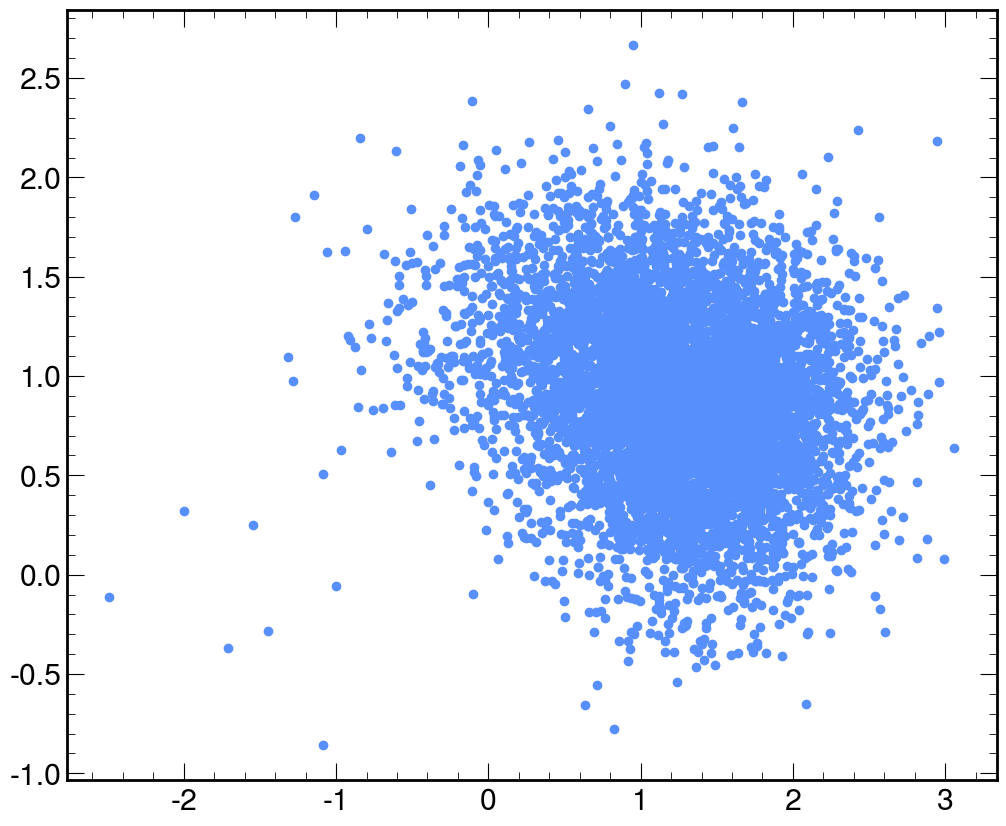

In [62]:
# mask = ~mask
# print((df_PTH_clean["r_PTH_45p0_80p0"] < 2).sum())

plt.figure(figsize=(12, 10))
plt.scatter(x=df_combined["r_YH_0p0_0p15"], y=df_combined["r_YH_0p3_0p6"])
# plt.xlim(0.995,1.005)
# plt.ylim(0.98,1.02)

# plt.xlabel(translation["r_PTH_200p0_350p0"])
# plt.ylabel(translation["r_PTH_45p0_80p0"])
# plt.show()
mask = (df_combined["r_YH_0p0_0p15"] > 0.5) & (df_combined["r_YH_0p0_0p15"] < 2.0) & (df_combined["r_YH_0p3_0p6"] > 0.5) & (df_combined["r_YH_0p3_0p6"] < 1.5)

print(mask.sum())

print(df_combined["r_YH_0p0_0p15"].corr(df_combined["r_YH_0p3_0p6"]))
print(df_combined[mask]["r_YH_0p0_0p15"].corr(df_combined[mask]["r_YH_0p3_0p6"]))
# print(df_PTH_clean["r_PTH_120p0_200p0"].corr(df_PTH_clean["r_PTH_15p0_30p0"]))

In [63]:
# 1️⃣ Define your stops and RGB values
stops = [0.0, 0.5, 1.0]
red   = [0.992, 1.0, 0.110]
green = [0.749, 1.0, 0.196]
blue  = [0.106, 1.0, 0.867]

# 2️⃣ Build the color dictionary
cdict = {
    'red':   [(stops[i], red[i], red[i]) for i in range(len(stops))],
    'green': [(stops[i], green[i], green[i]) for i in range(len(stops))],
    'blue':  [(stops[i], blue[i], blue[i]) for i in range(len(stops))]
}

# 3️⃣ Create the colormap
custom_cmap = LinearSegmentedColormap('gradient_8289', cdict)

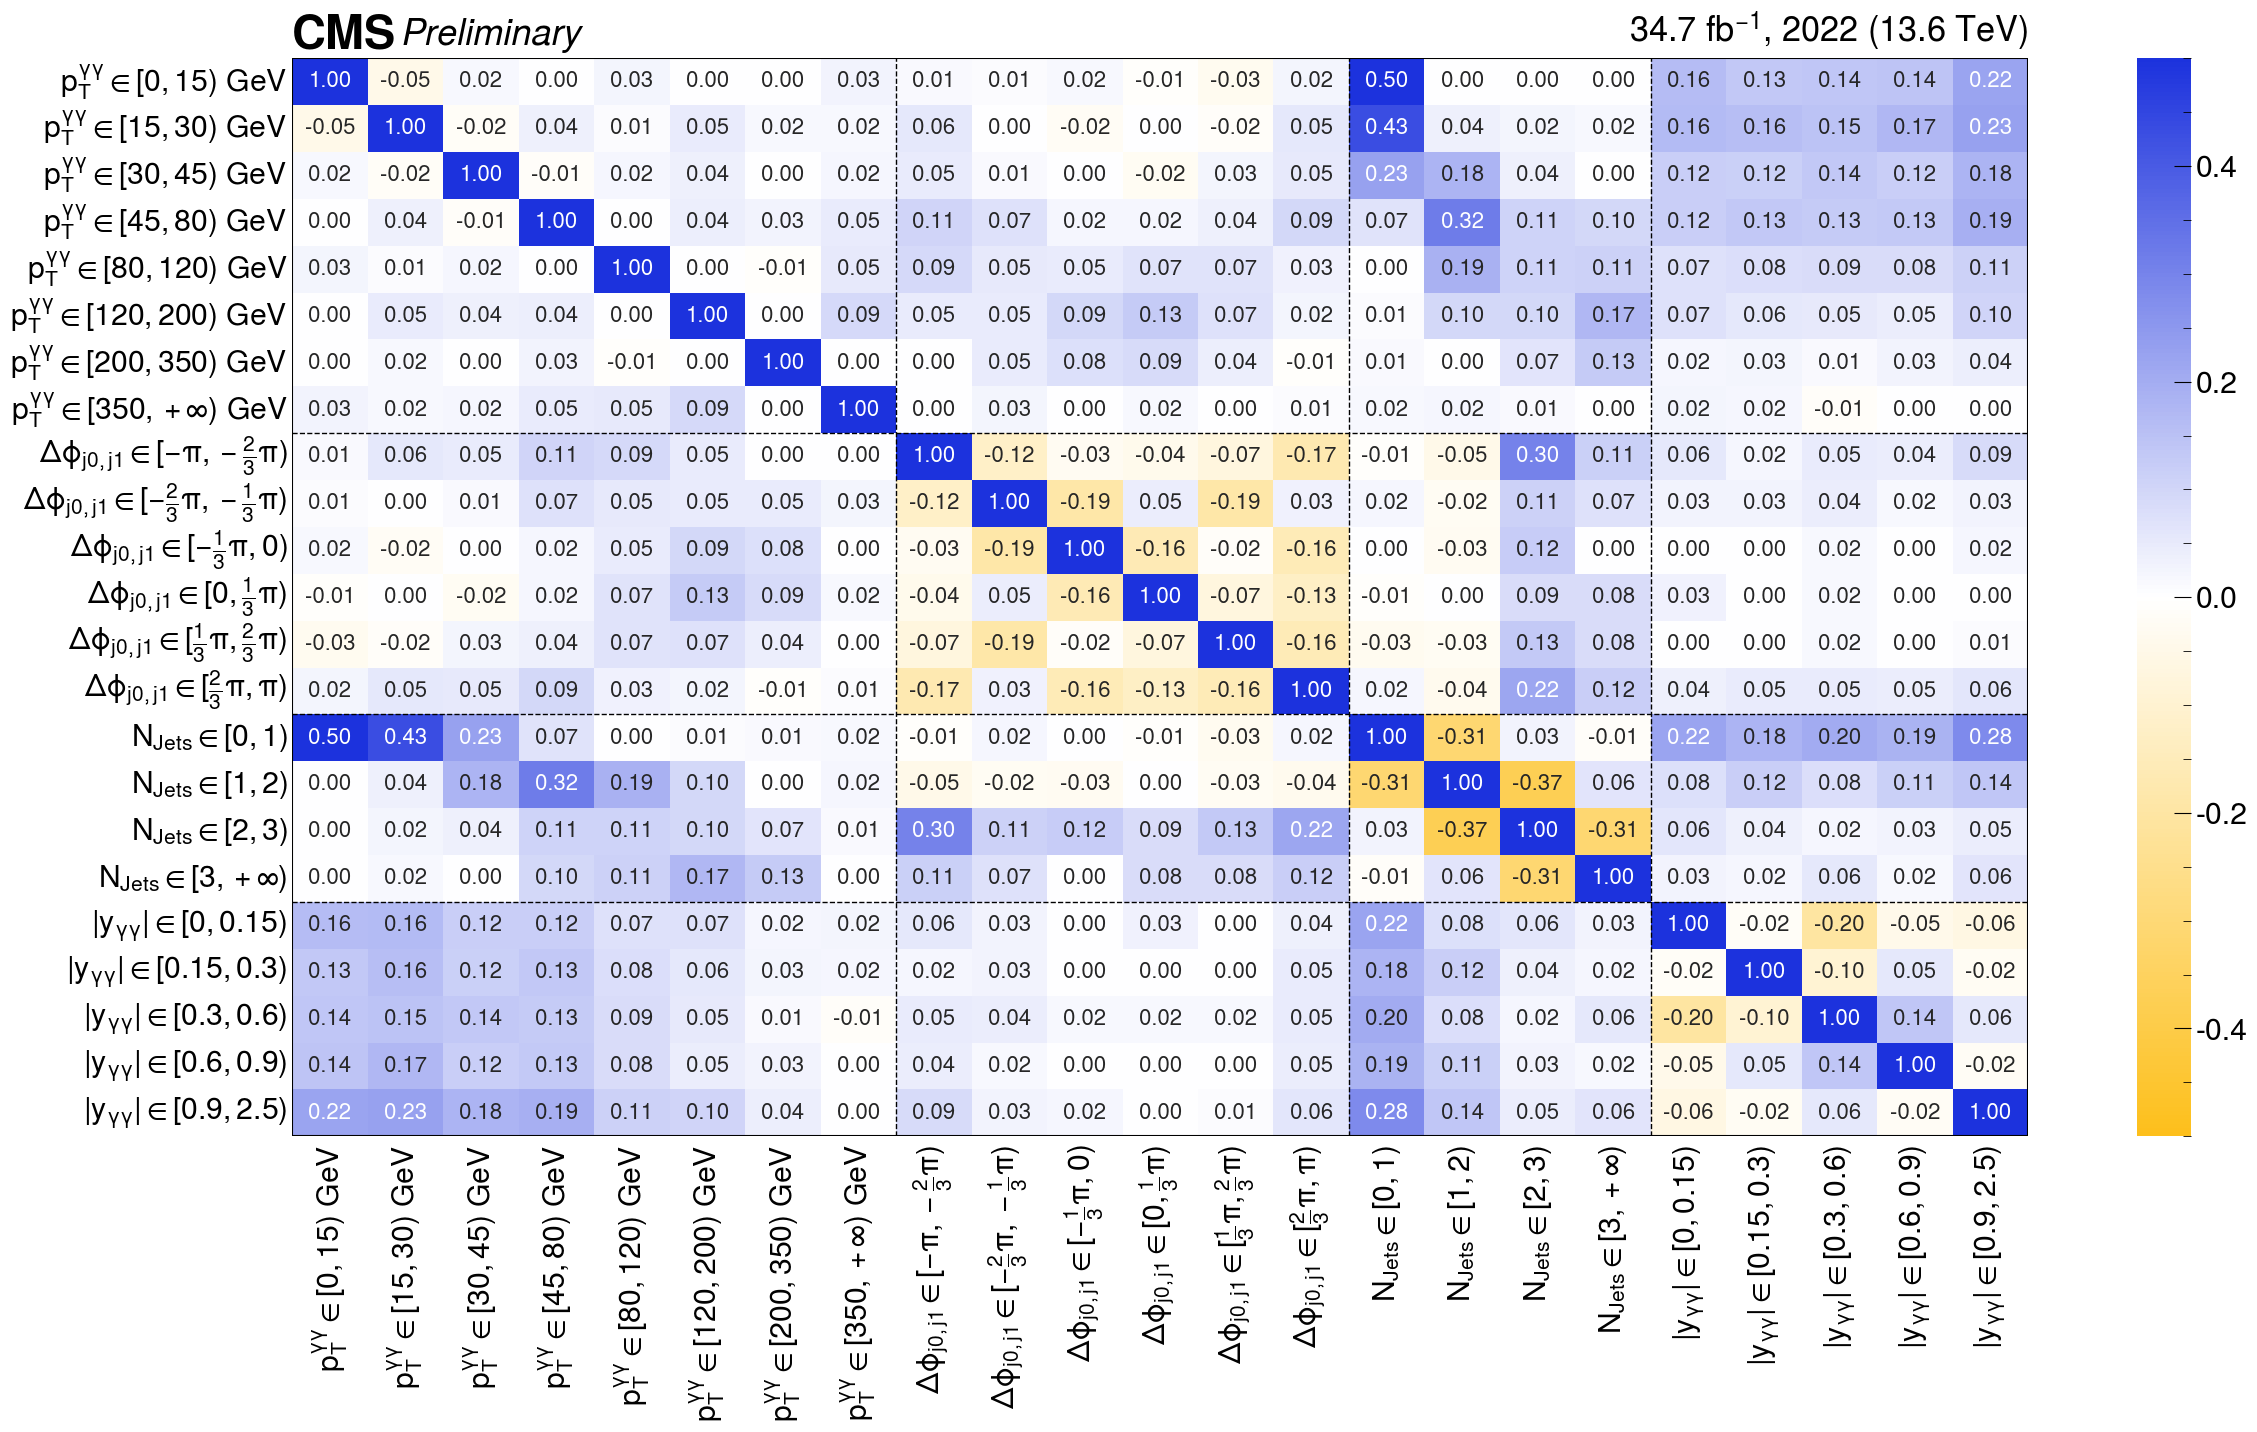

In [65]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix_translated = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=True, lumi=34.7, com=13.6, year=2022)
ax = sns.heatmap(modified_corr_matrix_translated, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix_translated.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 14, 18, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs_10k_finalVariables.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_obs_10k_finalVariables.png"), bbox_inches='tight')
# plt.show()

# plt.close()


In [23]:
# Convert DataFrame to list of dictionaries
modified_corr_matrix_dict = modified_corr_matrix.to_dict(orient="records")

# Write to YAML file
with open("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/output.yaml", "w", encoding="utf-8") as f:
    yaml.dump(modified_corr_matrix_dict, f, sort_keys=False, allow_unicode=True)

In [24]:
# Load YAML file
with open("/work/niharrin/t35/CMSSW_14_1_0_pre4/src/flashggFinalFit/Replicas/corr_matrix/Plots/output.yaml", "r", encoding="utf-8") as f:
    data = yaml.safe_load(f)

# Convert to DataFrame
df = pd.DataFrame(data)
df = df.set_index(df.columns)  # Set the first column as index

In [25]:
df

,r_PTH_0p0_15p0,r_PTH_15p0_30p0,r_PTH_30p0_45p0,r_PTH_45p0_80p0,r_PTH_80p0_120p0,r_PTH_120p0_200p0,r_PTH_200p0_350p0,r_PTH_350p0_10000p0,r_YH_0p0_0p15,r_YH_0p15_0p3,r_YH_0p3_0p6,r_YH_0p6_0p9,r_YH_0p9_2p5
r_PTH_0p0_15p0,1.000000,-0.067730,0.000000,-0.014256,0.000000,0.000000,-0.011175,-0.011192,0.163668,0.126967,0.106714,0.119530,0.243389
r_PTH_15p0_30p0,-0.067730,1.000000,-0.044625,0.033651,0.014706,0.013442,0.000000,0.000000,0.147872,0.176582,0.151046,0.149002,0.217576
r_PTH_30p0_45p0,0.000000,-0.044625,1.000000,-0.035096,0.015544,0.031617,-0.031074,0.000000,0.113524,0.089521,0.144641,0.134777,0.162310
r_PTH_45p0_80p0,-0.014256,0.033651,-0.035096,1.000000,-0.047425,0.060811,0.021490,0.013976,0.156486,0.119507,0.102473,0.143864,0.188724
r_PTH_80p0_120p0,0.000000,0.014706,0.015544,-0.047425,1.000000,0.027342,0.036386,0.011635,0.063486,0.092326,0.079634,0.081536,0.093881
r_PTH_120p0_200p0,0.000000,0.013442,0.031617,0.060811,0.027342,1.000000,-0.037075,0.036411,0.041355,0.056947,0.069812,0.087481,0.098945
r_PTH_200p0_350p0,-0.011175,0.000000,-0.031074,0.021490,0.036386,-0.037075,1.000000,-0.026397,0.034510,0.027615,0.014718,0.024148,0.000000
r_PTH_350p0_10000p0,-0.011192,0.000000,0.000000,0.013976,0.011635,0.036411,-0.026397,1.000000,0.014191,0.000000,0.000000,-0.016289,0.000000
r_YH_0p0_0p15,0.163668,0.147872,0.113524,0.156486,0.063486,0.041355,0.034510,0.014191,1.000000,-0.036883,-0.188214,-0.015159,-0.065590
r_YH_0p15_0p3,0.126967,0.176582,0.089521,0.119507,0.092326,0.056947,0.027615,0.000000,-0.036883,1.000000,-0.095587,0.025265,-0.016391


In [ ]:
# Try applying the third moments 

def calc_abc_dict(pois):
    # First, calculate the third moments for each POI
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in list(pois.keys())])
    abc_dict = {}
    for i, current_poi in enumerate(pois.keys()):
        # print(i, current_poi)
        r = np.array(pois[current_poi])
        r = r[r > -998.0]
        m_one = np.mean(r)
        m_two = cov_matrix[i][i]
        m_three = np.mean((r - m_one)**3)
        
        c_i = -np.sign(m_three) * np.sqrt(2 * m_two) * np.cos(((4* np.pi) / 3) + ((1/3) * np.arctan(np.sqrt((8 * (m_two**3 / m_three**2)) - 1))))
        b_i = np.sqrt(m_two - 2*(c_i**2))
        a_i = m_one - c_i
        abc_dict[current_poi] = (a_i, b_i, c_i)
    return abc_dict
        

In [ ]:
def calc_SL_rho(pois, abc_dict_):
    cov_matrix = np.cov([np.array(pois[current_poi_])[np.array(pois[current_poi_]) > -998.0] for current_poi_ in pois.keys()])
    poi_names = list(pois.keys())
    rho = []
    for i, current_poi in enumerate(pois.keys()):
        a_i, b_i, c_i = abc_dict_[current_poi]
        rho_i = []
        for j, other_poi in enumerate(pois.keys()):
            a_j, b_j, c_j = abc_dict_[other_poi]
            m_two_ij = cov_matrix[i][j]
            
            rho_ij = (1/(4*c_i*c_j)) * (np.sqrt((b_i**2 * b_j**2) + 8*(c_i*c_j*m_two_ij)) - (b_i * b_j))
            rho_i.append(rho_ij)
        rho.append(rho_i)
        
    rho_df = pd.DataFrame(rho, index=poi_names, columns=poi_names)
    return rho_df


In [ ]:
# Extend the pois to multplie variables
# combined_pois = {}
# for current_poi in poi_list:
#     combined_pois[current_poi] = pois_PTH[current_poi]
# for current_poi in poi_list_NJ:
#     combined_pois[current_poi] = pois_NJ[current_poi]

# combined_pois.keys()

combined_pois = df_combined.to_dict(orient='list')

In [ ]:
combined_pois

In [ ]:
abc_dict = calc_abc_dict(combined_pois)
corr_matrix = calc_SL_rho(combined_pois, abc_dict)

In [ ]:
modified_corr_matrix = corr_matrix.copy()
modified_corr_matrix = modified_corr_matrix.where(abs(modified_corr_matrix) >= 0.01, 0)  # Set values greater than 0.1 to 0

modified_corr_matrix = modified_corr_matrix.rename(index=translation, columns=translation)

plt.figure(figsize=(28, 14))
plt.style.use(hep.style.CMS)
hep.cms.label('Preliminary', data=False, lumi=9.5, com=13.6)
ax = sns.heatmap(modified_corr_matrix, annot=True, cmap=custom_cmap, vmin=-0.5, vmax=0.5, annot_kws={"size": 16}, linewidths=0.0, linecolor='black', fmt=".2f")

ax.tick_params(
    axis='both',      # apply to both axes
    which='both',     # apply to both major and minor ticks
    bottom=False,     # remove bottom ticks
    top=False,        # remove top ticks
    left=False,       # remove left ticks
    right=False,      # remove right ticks
    labelbottom=True, # keep labels if you want
    labelleft=True    # keep labels if you want
)

# Get the number of rows and columns
n_rows, n_cols = modified_corr_matrix.shape

# Add rectangle around the whole heatmap to complete the outer box
rect = Rectangle(
    (0, 0),          # bottom left corner
    width=n_cols,    # number of columns
    height=n_rows,   # number of rows
    fill=False,      # no fill, just the edge
    edgecolor='black',
    linewidth=1.5
)
ax.add_patch(rect)

# Define group boundaries (between variable blocks)
group_boundaries = [8, 12, 17, 23]  # Example indices between variable blocks # 8, 14, 18, 23

# Draw thick lines between groups
for boundary in group_boundaries:
    ax.axhline(boundary, color='black', linewidth=1, linestyle='--')
    ax.axvline(boundary, color='black', linewidth=1, linestyle='--')

plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.pdf"), bbox_inches='tight')
plt.savefig(os.path.join(plot_dir, "correlation_matrix_abc.png"), bbox_inches='tight')
plt.show()

In [ ]:
z_hat = 0.5 * np.log((1 + corr_matrix) / (1 - corr_matrix)) + (corr_matrix / (2*(len(df_combined) - 2)))
a = np.tanh(z_hat - np.sqrt(1 / (len(df_combined) - 3)))
b = np.tanh(z_hat + np.sqrt(1 / (len(df_combined) - 3)))

In [ ]:
# From Wikipedia https://en.wikipedia.org/wiki/Pearson_correlation_coefficient
import numpy as np
t_values = np.sqrt((1 - corr_matrix**2) / (len(df_combined) - 2))
np.fill_diagonal(t_values.values, 0)
sigma = t_values.max().max()

In [ ]:
sigma